In [85]:
#%% Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
#plotly.express 是 Plotly 库的一个高级接口，专为快速创建各种图表而设计。
#Plotly 是一个用于制作交互式图形的库，
import seaborn as sns
import shap
#shap 是一个用于解释机器学习模型输出的 Python 库，其全称是 SHapley Additive exPlanations。
#它基于博弈论中的 Shapley 值，提供了一种统一的衡量每个特征对预测结果贡献的方法。
#shap 库能够帮助我们理解复杂模型（如深度学习、梯度提升树等）的决策过程，从而提高模型的透明性和可解释性。
import lightgbm as lgb
#lightgbm（通常简称为 lgb）是一个基于梯度提升决策树（GBDT, Gradient Boosting Decision Tree）算法
#的高效机器学习库。它由微软开发，旨在提高模型训练的速度和效率，同时保持高精度。
#LightGBM 通过引入直方图算法、叶子生长策略、直方图做差加速以及数据预排序等技术，
#实现了比其他同类库更快的训练速度和更低的内存消耗。
%matplotlib inline

from matplotlib import pyplot
from pprint import pprint
# Python 中用于美化打印（pretty-printing）的语句。
#pprint 函数来自于 pprint 模块，它提供了一种更易读的方式来输出复杂的数据结构，如字典、列表、元组等嵌套对象。
from IPython.display import display 
#Jupyter Notebook、JupyterLab 以及其他基于 IPython 的环境中非常有用的一个导入语句。
#display 函数允许你以一种更丰富和灵活的方式输出数据，
from sklearn import model_selection
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, roc_auc_score, precision_score
from sklearn.model_selection import RandomizedSearchCV

In [86]:
#%% Read raw data 
data_raw = pd.read_csv('./BankChurners.csv')
# Columns to be dropped
drop_columns = ['CLIENTNUM',
                'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']

# Remove CLIENTNUM and the Naive_Bayes_Classifiers
data_raw = data_raw.drop(drop_columns,errors='ignore',axis=1)
# Initial glance at data
display(data_raw.info())
# Check for missing or NaN data 
print("No Missing Data in this Dataset")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

None

No Missing Data in this Dataset


In [87]:
#%% MultiColumnLabelEncoder
# Code snipet found on Stack Exchange 
# https://stackoverflow.com/questions/24458645/label-encoding-across-multiple-columns-in-scikit-learn
# from sklearn.preprocessing import LabelEncoder

class MultiColumnLabelEncoder:
    def __init__(self,columns = None):
        self.columns = columns 

    def fit(self,X,y=None):
        return self # not relevant here

    def transform(self,X):
        '''
        Transforms columns of X specified in self.columns using
        LabelEncoder(). If no columns specified, transforms all
        columns in X.
        '''
        output = X.copy()
        if self.columns is not None:
            for col in self.columns:
                # convert float NaN --> string NaN
                output[col] = output[col].fillna('NaN')
                output[col] = LabelEncoder().fit_transform(output[col])
        else:
            for colname,col in output.iteritems():
                output[colname] = LabelEncoder().fit_transform(col)
        return output

    def fit_transform(self,X,y=None):
        return self.fit(X,y).transform(X)

#%% Recreate X and y from data_raw
y = data_raw['Attrition_Flag']
X = data_raw.drop('Attrition_Flag',errors='ignore',axis=1)

# store the catagorical features names as a list      
cat_features = X.select_dtypes(['object']).columns.to_list()

# use MultiColumnLabelEncoder to apply LabelEncoding on cat_features 
# uses NaN as a value , no imputation will be used for missing data
X_Encoded = MultiColumnLabelEncoder(columns = cat_features).fit_transform(X)

In [88]:
#%% Before and After Label Encoding for y
y_Encoded = y.replace({'Existing Customer': 0, 'Attrited Customer': 1})
display(y)
display(y_Encoded)

C:\Users\86188\AppData\Local\Temp\ipykernel_29268\3552172404.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_Encoded = y.replace({'Existing Customer': 0, 'Attrited Customer': 1})


0        Existing Customer
1        Existing Customer
2        Existing Customer
3        Existing Customer
4        Existing Customer
               ...        
10122    Existing Customer
10123    Attrited Customer
10124    Attrited Customer
10125    Attrited Customer
10126    Attrited Customer
Name: Attrition_Flag, Length: 10127, dtype: object

0        0
1        0
2        0
3        0
4        0
        ..
10122    0
10123    1
10124    1
10125    1
10126    1
Name: Attrition_Flag, Length: 10127, dtype: int64

In [89]:
train_x,valid_x,train_y,valid_y=train_test_split(X_Encoded,y_Encoded,test_size=0.2)
# 创建训练集和验证集
train_data = lgb.Dataset(train_x, label=train_y, categorical_feature=cat_features)
valid_data = lgb.Dataset(valid_x, label=valid_y, categorical_feature=cat_features)

# 选择超参数
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'colsample_bytree': 0.9234,
    'num_leaves': 13,
    'max_depth': -1,
    'n_estimators': 200,
    'min_child_samples': 399,
    'min_child_weight': 0.1,
    'reg_alpha': 2,
    'reg_lambda': 5,
    'subsample': 0.855,
    'verbose': -1,
    'num_threads': 4
}

In [90]:
# 训练模型
lgbm = lgb.train(
    params,
    train_data,
    num_boost_round=2500,
    valid_sets=[valid_data],  # 使用列表传递验证集
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=True),  # 早停回调
        lgb.log_evaluation(period=10)  # 每 10 轮输出一次评估结果
    ]
)

D:\develop\Anaconda\envs\myenvy\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Training until validation scores don't improve for 30 rounds
[10]	valid_0's auc: 0.962307
[20]	valid_0's auc: 0.971424
[30]	valid_0's auc: 0.980432
[40]	valid_0's auc: 0.984935
[50]	valid_0's auc: 0.987198
[60]	valid_0's auc: 0.988009
[70]	valid_0's auc: 0.988939
[80]	valid_0's auc: 0.989661
[90]	valid_0's auc: 0.990067
[100]	valid_0's auc: 0.990441
[110]	valid_0's auc: 0.990595
[120]	valid_0's auc: 0.990849
[130]	valid_0's auc: 0.990962
[140]	valid_0's auc: 0.991133
[150]	valid_0's auc: 0.99134
[160]	valid_0's auc: 0.991445
[170]	valid_0's auc: 0.991444
[180]	valid_0's auc: 0.991647
[190]	valid_0's auc: 0.991746
[200]	valid_0's auc: 0.991848
Did not meet early stopping. Best iteration is:
[200]	valid_0's auc: 0.991848


In [91]:
#%% Overall AUC
y_hat = lgbm.predict(X_Encoded)
score = roc_auc_score(y_Encoded, y_hat)
print("Overall AUC: {:.3f}" .format(score))

Overall AUC: 0.997


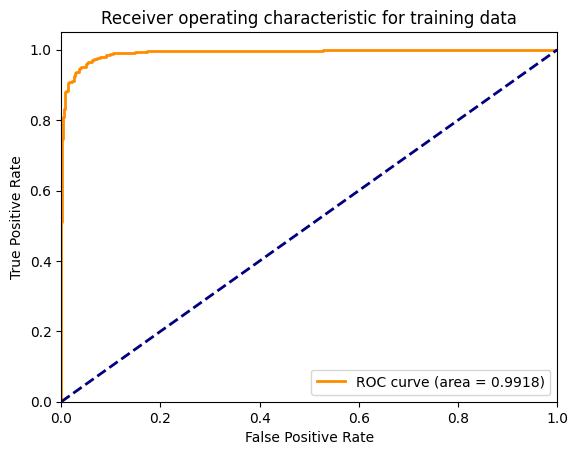

In [92]:
#%% ROC Curve for training/validation data
# https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py
y_probas = lgbm.predict(valid_x) 
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(valid_y, y_probas)
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic for training data')
plt.legend(loc="lower right")
plt.show()

In [93]:
# Great Function found on Kaggle for plotting a Confusion Matrix
# https://www.kaggle.com/grfiv4/plot-a-confusion-matrix
def plot_confusion_matrix_kaggle(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

# binarize an array based of a threshold 
def binarizeArray(array,threshold = 0.5):
    return [0 if num < threshold else 1 for num in array]

Best Threshold=0.167943, G-Mean=0.956


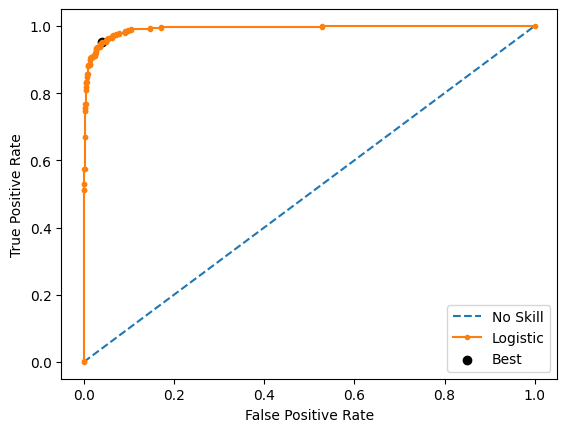

In [94]:
#%% Plot ROC curve and find best threshold to binarize the predictions from LGBM
# https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/
pred_y = lgbm.predict(valid_x)
# calculate roc curves
fpr, tpr, thresholds = roc_curve(valid_y, pred_y)
# calculate the g-mean for each threshold
gmeans = np.sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = np.argmax(gmeans)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds[ix], gmeans[ix]))
# plot the roc curve for the model
pyplot.figure(num=0, figsize=[6.4, 4.8])
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='Logistic')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
# show the plot
pyplot.show()

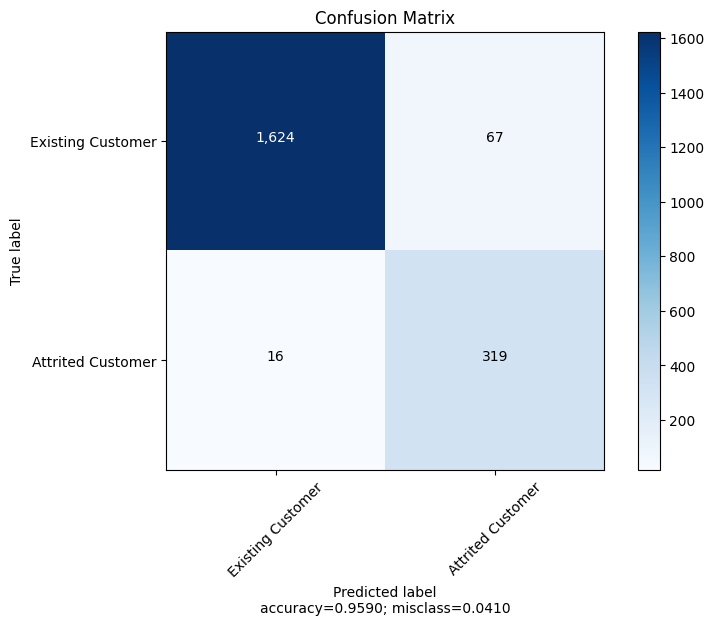

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1691
           1       0.83      0.95      0.88       335

    accuracy                           0.96      2026
   macro avg       0.91      0.96      0.93      2026
weighted avg       0.96      0.96      0.96      2026

Accuracy: 95.90%
Recall: 95.22%


In [95]:
#%% Plot Confusion Matrix with best threshold
pref_y_bin = binarizeArray(pred_y,thresholds[ix])
cm = confusion_matrix(valid_y,pref_y_bin)
plot_confusion_matrix_kaggle(cm =cm, 
                      normalize    = False,
                      target_names = ['Existing Customer', 'Attrited Customer'],
                      title        = "Confusion Matrix")
print(classification_report(valid_y,pref_y_bin))
print("Accuracy: %.2f%%" % (accuracy_score(valid_y, pref_y_bin)*100.0))
print("Recall: %.2f%%" % ((recall_score(valid_y,pref_y_bin))*100.0))

D:\develop\Anaconda\envs\myenvy\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


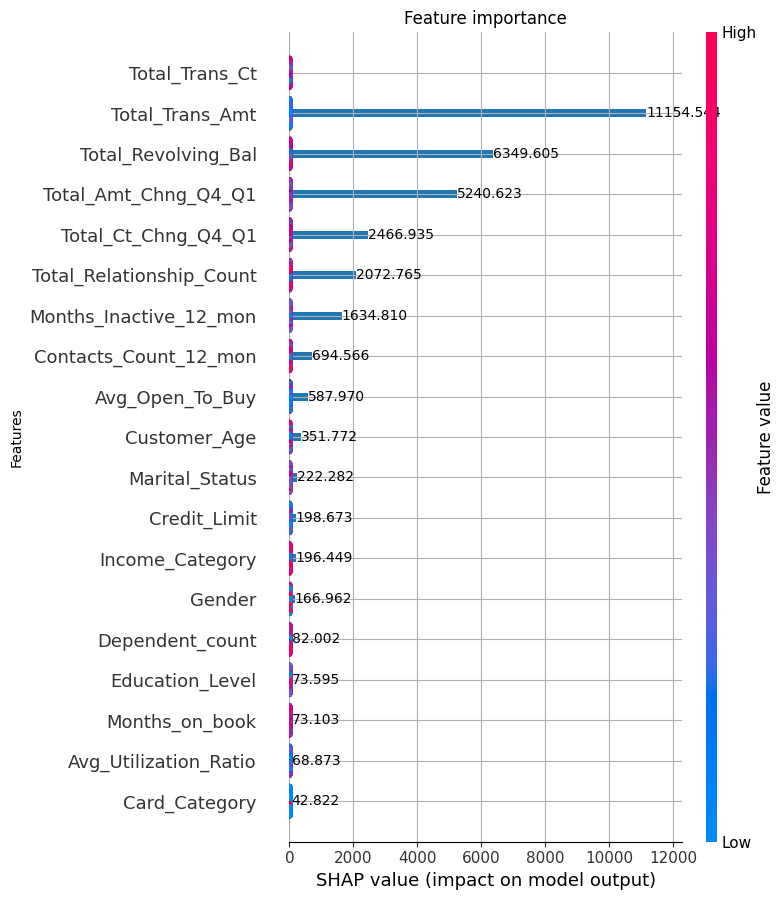

In [96]:
##% Feature Importance using shap package 
ax = lgb.plot_importance(lgbm, figsize=(15, 10), max_num_features=20, importance_type='gain')
lgbm.params['objective'] = 'binary'
shap_values = shap.TreeExplainer(lgbm).shap_values(X_Encoded)
shap.summary_plot(shap_values, X_Encoded)



In [97]:
lgb.plot_importance(lgbm,figsize=(15,10))

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

D:\develop\Anaconda\envs\myenvy\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


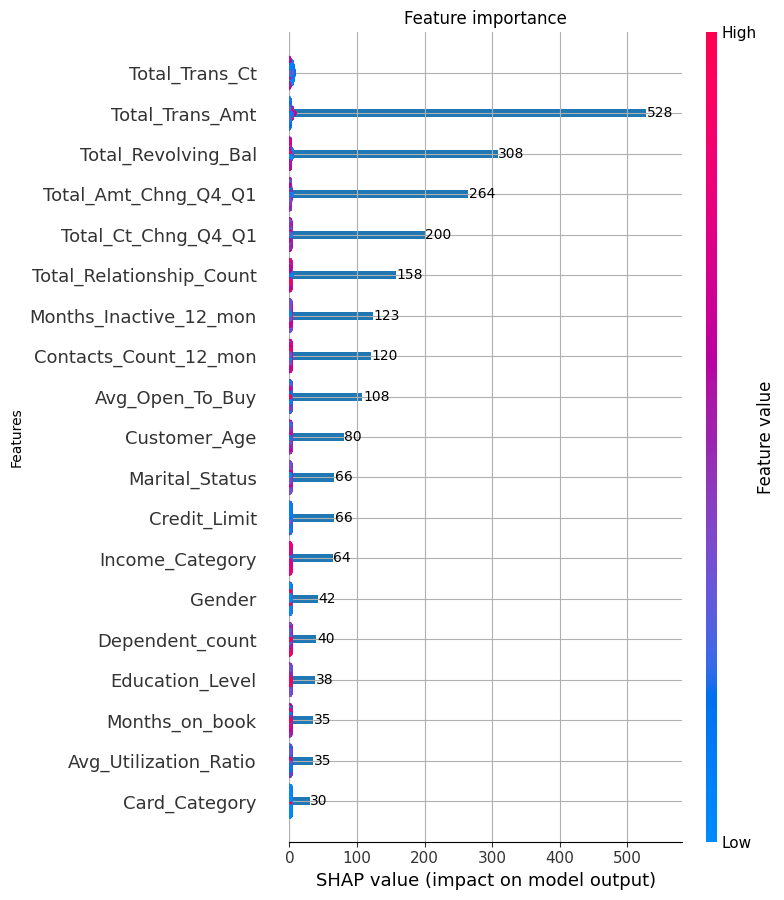

In [98]:
##% Feature Importance using shap package 
lgbm.params['objective'] = 'binary'
shap_values = shap.TreeExplainer(lgbm).shap_values(X_Encoded)
shap.summary_plot(shap_values, X_Encoded)

The most important features appear to be Total_Trans_Ct, Total_Trans_Amt, and Total_Revolving_Bal. It appears that numeric features compared to categorical features give more value in determining whether or not a customer churn or not. 